In [32]:
import pandas as pd
import numpy as np
import ot
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
import pickle

In [34]:
df = pd.read_csv("mds_all_integrated_harmony.csv")
pc_cols = [f"harmony_{i}" for i in range(1, 51)]

In [20]:
df = pd.read_csv("mds_all.csv")
pc_cols = [f"pca_{i}" for i in range(1, 51)]

In [35]:
stage_pairs = [
    ("E12.5", "E13.5"),
    ("E13.5", "E14.5"),
    ("E14.5", "E15.5"),
    ("E15.5", "E17.5"),
    ("E17.5", "P0"),
    ("P0", "P4"),
]
color_map = {
    "progenitor": "#6abd12",
    "MBO": "#bce590",

    "VZ_neuroblast_1": "#facc15",
    "VZ_neuroblast_2": "#fde047",
    "VZ_neuroblast_3": "#fef08a",

    "NTZ_neuroblast_1": "#7d5207",
    "NTZ_neuroblast_2": "#b39054",
    "NTZ_neuroblast_3": "#ecd09f",

    "GCP": "#7f1d1d",
    "GC_diff_1": "#f76161",
    "GC_diff_2": "#ff9f9f",
    "GC_defined": "#ffd5d5",

    "GCP/UBCP": "#f27500",
    "GC/UBC_diff": "#fb9f4a",
    "UBC_diff": "#f7b272",
    "UBC_defined": "#fdc999",

    "Purkinje_diff": "#0a229b",
    "Purkinje_defined": "#90a2f2",
    "Purkinje_maturing": "#cbd4f9",

    "interneuron_diff": "#069372",
    "interneuron_defined": "#7cd9c3",
    "GABA_DN_defined": "#c2ece2",

    "glut_DN_defined": "#ae3970",
    "isth_N_diff": "#fdb8e9",
    "isth_N_defined": "#ffe1f7",

    "glioblast": "#550584",
    "oligo_progenitor": "#8c2ebf",
    "oligodendrocyte": "#c38ce3",
    "astrocyte": "#d7c8f0",
    
    "meningeal": "#1a1a1a",
    "parabrachial": "#4d4d4d"
}

In [36]:
def compute_ot(df, stage1, stage2, pc_cols, reg, anno_penalty, dist_power=1):

    A = df[df["stage"] == stage1].copy()
    B = df[df["stage"] == stage2].copy()

    XA = A[pc_cols].to_numpy()
    XB = B[pc_cols].to_numpy()

    C = pairwise_distances(XA, XB, metric="euclidean")

    if dist_power != 1:
        C = C ** dist_power

    C = C / np.median(C)

    anno_A = A["annotation"].to_numpy()
    anno_B = B["annotation"].to_numpy()

    mismatch = anno_A[:, None] != anno_B[None, :]
    C[mismatch] += anno_penalty

    a = np.ones(len(A)) / len(A)
    b = np.ones(len(B)) / len(B)

    T = ot.sinkhorn(
        a, b, C,
        reg=reg,
        numItermax=5000,
        stopThr=1e-4)

    return A, B, T

In [37]:
def compute_vector(df, A, B, T, n_grid=12, x="MDS_1", y="MDS_2", min_cells = 30):
    import numpy as np

    start = A[[x, y]].to_numpy()
    end = B[[x, y]].to_numpy()

    k = 10
    target = np.full((T.shape[0], end.shape[1]), np.nan)  
    
    for i in range(T.shape[0]):
        w = T[i].copy()
    
        idx = np.argsort(w)[::-1][:k]
        ww = w[idx]
    
        if ww.sum() == 0:
            continue
    
        ww = ww / ww.sum()
        target[i] = ww @ end[idx]
    
    flow = A.copy()
    flow["target_x"] = target[:, 0]
    flow["target_y"] = target[:, 1]
    flow["vx"] = flow["target_x"] - flow[x]
    flow["vy"] = flow["target_y"] - flow[y]



    x_edges = np.linspace(df[x].min(), df[x].max(), n_grid + 1)
    y_edges = np.linspace(df[y].min(), df[y].max(), n_grid + 1)

    flow["gx"] = np.digitize(flow[x], x_edges) - 1
    flow["gy"] = np.digitize(flow[y], y_edges) - 1

    flow = flow[
        (flow["gx"] >= 0) & (flow["gx"] < n_grid) &
        (flow["gy"] >= 0) & (flow["gy"] < n_grid)
    ].copy()

    flow["gid"] = flow["gy"] * n_grid + flow["gx"]

    grid_vec = (
        flow.groupby("gid")
        .agg(
            x=(x, "mean"),
            y=(y, "mean"),
            vx=("vx", "mean"),
            vy=("vy", "mean"),
            n_cells=("gid", "size")
        )
        .reset_index()
    )

    grid_vec = grid_vec[grid_vec["n_cells"] >= min_cells].copy()
    
    return grid_vec

In [40]:
def plot_ot_vector(
    df,
    stage1,
    stage2,
    pc_cols,
    reg=0.05,
    anno_penalty = 0,
    n_grid=12,
    x="MDS_1",
    y="MDS_2",
    min_cells = 20,
    save_path=None,
    ax=None,
    ifa = 1,
):
    A, B, T = compute_ot(df=df, stage1=stage1, stage2=stage2, pc_cols=pc_cols, reg=reg, anno_penalty = anno_penalty)
    grid_vec = compute_vector(df = df, A=A, B=B, T=T, n_grid=n_grid, x=x, y=y, min_cells= min_cells)
    bg = df[df["stage"].isin([stage1, stage2])].copy()

    for anno, sub in bg.groupby("annotation"):
        sub1 = sub[sub["stage"] == stage1]
        sub2 = sub[sub["stage"] == stage2]
    

    
        if ifa == 1:
            ax.scatter(
                sub1[x], sub1[y],
                s=2, alpha=0.8,
                color=color_map.get(anno),
                zorder=1)
    
            ax.scatter(
                sub2[x], sub2[y],
                s=2, alpha=0.8,
                color="lightgrey",
                zorder = 2 )
            
        else:
            ax.scatter(
                sub1[x], sub1[y],
                s=2, alpha=0.8,
                color="lightgrey",
                zorder = 1)

    
            ax.scatter(
                sub2[x], sub2[y],
                s=2, alpha=0.8,
                color=color_map.get(anno),
                zorder = 2)

    ax.quiver(
        grid_vec["x"], grid_vec["y"], grid_vec["vx"], grid_vec["vy"],
        angles="xy", scale_units="xy", scale=1, width=0.004, headwidth= 7, headlength = 9,
        zorder = 3)
    
    ax.set_aspect("equal")
    ax.set_xlabel(x)
    ax.set_ylabel(y)


    return grid_vec

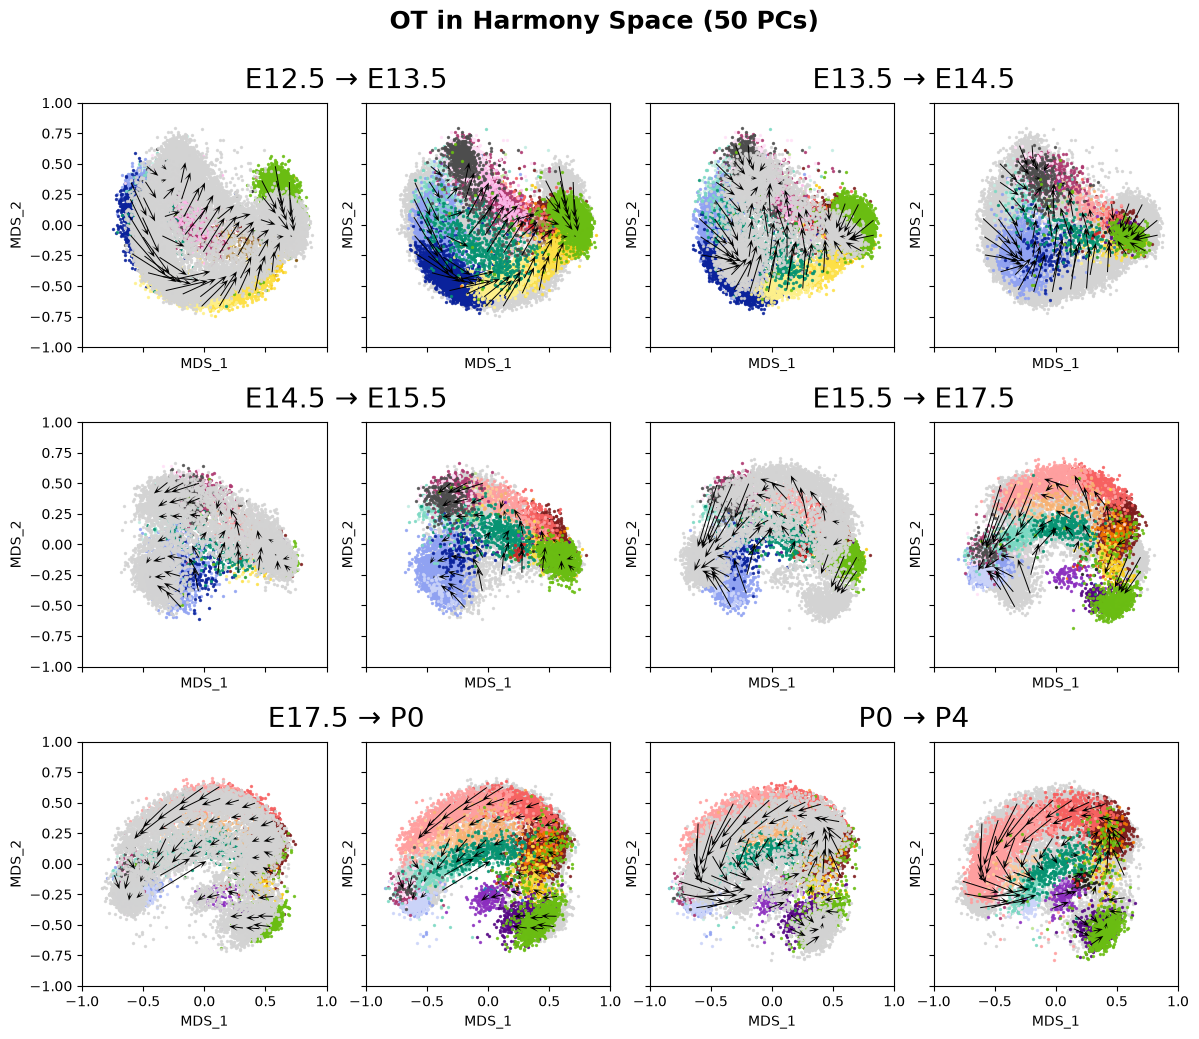

In [42]:
fig, axes = plt.subplots(
    3, 4,
    figsize=(12, 10),
    sharex=True,
    sharey=True)

axes = axes.ravel()

grid_vecs = {}
pair_axes = []

for i, (stage1, stage2) in enumerate(stage_pairs):

    ax1 = axes[i * 2]
    ax2 = axes[i * 2 + 1]

    grid_vecs[f"{stage1}_to_{stage2}_ifa_1"] = plot_ot_vector(
        df=df,
        stage1=stage1,
        stage2=stage2,
        pc_cols=pc_cols,
        ax=ax1,
        ifa=1)

    grid_vecs[f"{stage1}_to_{stage2}_ifa_2"] = plot_ot_vector(
        df=df,
        stage1=stage1,
        stage2=stage2,
        pc_cols=pc_cols,
        ax=ax2,
        ifa=2)

    for ax in [ax1, ax2]:
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_aspect("equal")
        ax.set_title("")

    pair_axes.append((ax1, ax2, stage1, stage2))

plt.tight_layout(h_pad=1.0, w_pad=0.3)

for ax1, ax2, stage1, stage2 in pair_axes:

    pos1 = ax1.get_position()
    pos2 = ax2.get_position()

    center_x = (pos1.x0 + pos2.x1) / 2
    title_y = max(pos1.y1, pos2.y1) + 0.008

    fig.text(
        center_x,
        title_y,
        f"{stage1} → {stage2}",
        ha="center",
        va="bottom",
        fontsize=20)

fig.suptitle(
    "OT in Harmony Space (50 PCs)",
    fontsize=18,
    fontweight="bold",
    y=1.05
)

plt.savefig(
    "OT_vector_patch_3x4.png",
    dpi=200,
    bbox_inches="tight")

plt.show()